# Train and Evaluate the Model

- Load the previously created dataset from huggingface

- set up the training arguments

- train

- evaluate

In [19]:
import random
import numpy as np
import torch

seed = 18
random.seed(seed)
torch.manual_seed(seed)

# Select device:
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.manual_seed_all(seed)
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")


Using device: mps


# Load the Dataset from HuggingFace

In [20]:
from datasets import load_dataset

dataset = load_dataset("Rogarcia18/symptoms_ner_v00")
# NOTE that the actual labels that will be used for training are under the column: "token_label_ids"
dataset = dataset.rename_column("token_label_ids", "labels")


# Setup Training Arguments

In [3]:
# from google.colab import userdata
# HF_TOKEN = userdata.get('HF_TOKEN')
# WANDB_API_KEY = userdata.get('WANDB_API_KEY')
# os.environ["HF_TOKEN"] = HF_TOKEN
# os.environ["WANDB_API_KEY"] = WANDB_API_KEY

In [21]:
import os
import json
from dotenv import load_dotenv
from transformers import (
    TrainingArguments,
    Trainer,
    DistilBertTokenizerFast,
    DistilBertForTokenClassification,
    DataCollatorForTokenClassification,
)

load_dotenv()
os.environ.setdefault("WANDB_PROJECT", "symptom-ner")

# Load id2label and label2id mappings from json files
with open("id2label.json", "r") as f:
    id2label = json.load(f)
with open("label2id.json", "r") as f:
    label2id = json.load(f)

# Set up the tokenizer and model
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
num_labels = len(id2label)
model = DistilBertForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
    ).to(device)


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:

OUTPUT_DIR = "distilBERT-symptom-ner-v00"
EVAL_STRATEGY = "epoch"  # simple
# Learning rates to experiment with:
LEARNING_RATES = [5e-5, 3e-5, 1e-5]
# Bs to experiment with:
BS = [10, 16, 32, 64]
NUM_EPOCHS = [20]
run_index = 0

# FIRST ARGUMENTS
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy=EVAL_STRATEGY,
    push_to_hub=True,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,  # 1 epoch likely underfits; 3 is still quick
    weight_decay=0.01,  # same as in video: https://www.youtube.com/watch?v=ujubwa_oa-0
    warmup_ratio=0.1,  # smooth LR start for small data; drop if you want pure simplicity
    save_strategy="epoch",  # align checkpointing with eval
    logging_strategy="epoch",  # keep logging light
    load_best_model_at_end=True,  # restores best checkpoint
    metric_for_best_model="macro_f1",  # macro_f1 is returned by compute_metrics
    report_to=["wandb"],  # enable Weights & Biases logging
    run_name=f"runs/distilbert-symptom-ner-v00-run-{run_index}",  # shows in W&B runs; adjust as needed
)


# Train !

In [23]:
from metrics import compute_metrics, compute_per_label_metrics, plot_metrics

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"].select(range(5)),
    eval_dataset=dataset["validation"].select(range(5)),
    tokenizer=tokenizer,
    data_collator=data_collator,
    # call compute_metrics with the argument id2label=id2label
    compute_metrics=lambda eval_pred: compute_metrics(eval_pred, id2label=id2label),
)

/var/folders/9v/0z2cy6c546g6bvh2dzly39x80000gn/T/ipykernel_15927/74524172.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [24]:
# Uncomment to train
training_results = trainer.train()
# Log history: trainer.state.log_history[1].keys()

wandb: WARNING Serializing object of type dict that is 103856 bytes
wandb: WARNING Serializing object of type dict that is 103856 bytes
/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,8.253500,8.163195,0.000000,0.000000,0.000000,0.000000,0.000000
2,8.255200,7.937325,0.027778,0.000000,0.000000,0.000000,0.000000
3,7.952500,7.824402,0.138889,0.000000,0.000000,0.000000,0.000000


/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


# Evaluation 

In [25]:
from IPython.display import Image

## Validation Set

In [26]:
mini_validation = dataset["validation"].select(range(5))

In [27]:

print("=" * 60)
print("VALIDATION SET EVALUATION")
print("=" * 60)
val_metrics = trainer.evaluate(eval_dataset=mini_validation)
print("\nOverall Metrics (Validation):")
print(json.dumps(val_metrics, indent=2))

VALIDATION SET EVALUATION


/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Overall Metrics (Validation):
{
  "eval_loss": 8.16319465637207,
  "eval_accuracy": 0.0,
  "eval_precision": 0.0,
  "eval_recall": 0.0,
  "eval_f1": 0.0,
  "eval_macro_f1": 0.0,
  "eval_runtime": 0.0464,
  "eval_samples_per_second": 107.652,
  "eval_steps_per_second": 21.53,
  "epoch": 3.0
}



Computing per-label metrics for validation set...

✓ Per-label metrics computed for 29 labels
✓ Macro F1: 0.0000
✓ Metrics saved to: val_per_label_metrics.json
✓ Validation plot saved to: per_label_f1.png


/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


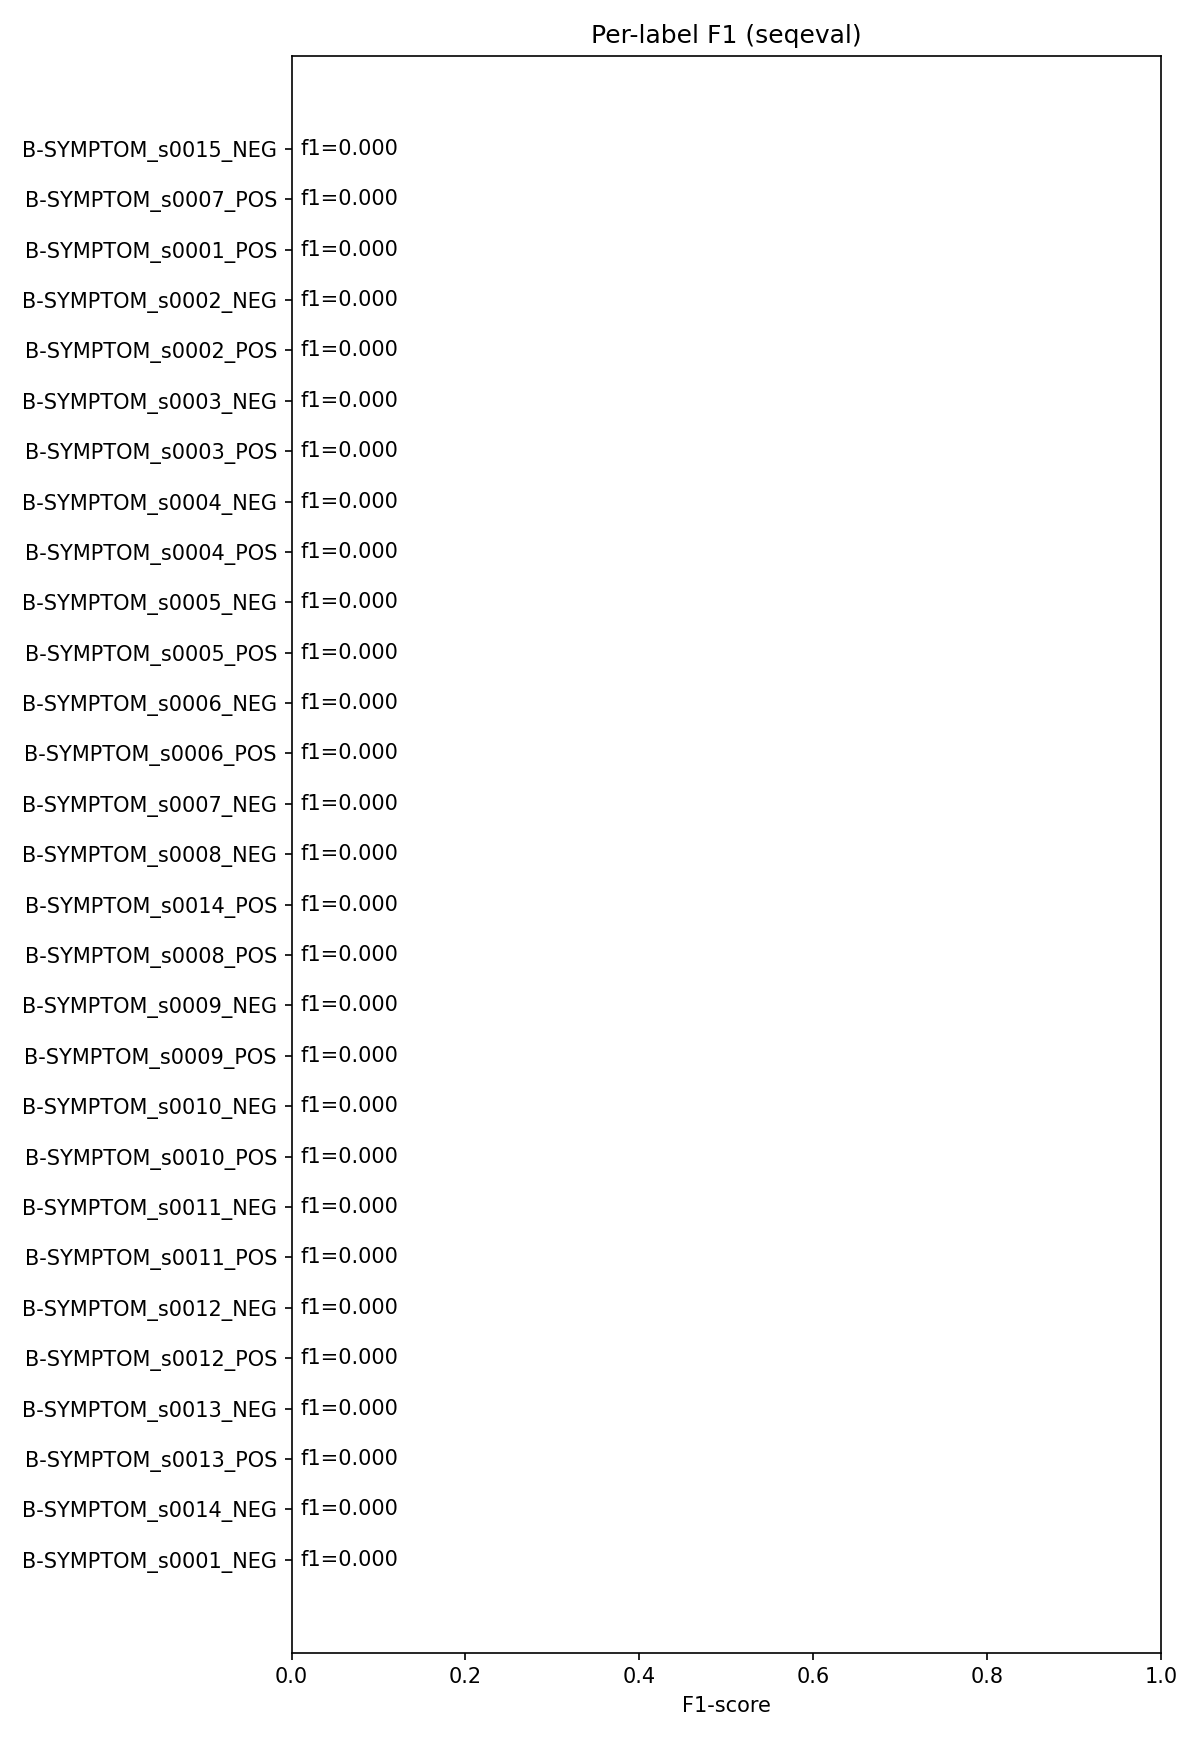

In [28]:
# Get predictions on validation set for detailed analysis
print("\n" + "=" * 60)
print("Computing per-label metrics for validation set...")
print("=" * 60)

val_predictions = trainer.predict(mini_validation)

# Compute per-label metrics
val_per_label_metrics = compute_per_label_metrics(
    val_predictions, 
    id2label=id2label,
    save_path="val_per_label_metrics.json"
)

print(f"\n✓ Per-label metrics computed for {len(val_per_label_metrics['f1'])} labels")
print(f"✓ Macro F1: {val_per_label_metrics['macro_f1']:.4f}")
print(f"✓ Metrics saved to: val_per_label_metrics.json")

# Generate and display the plot
val_plot_path = plot_metrics(
    metrics=val_per_label_metrics,
    #save_path="val_per_label_f1.png",
    top_k=30  # Plot top 30 labels by F1 score
)


print(f"✓ Validation plot saved to: {val_plot_path}")
display(Image(val_plot_path))

# Test Set

In [29]:
mini_test = dataset['test'].select(range(5))

In [30]:

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
val_metrics = trainer.evaluate(eval_dataset=mini_test)
print("\nOverall Metrics (Validation):")
print(json.dumps(val_metrics, indent=2))

TEST SET EVALUATION


/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Overall Metrics (Validation):
{
  "eval_loss": 8.13408374786377,
  "eval_accuracy": 0.0,
  "eval_precision": 0.0,
  "eval_recall": 0.0,
  "eval_f1": 0.0,
  "eval_macro_f1": 0.0,
  "eval_runtime": 0.0762,
  "eval_samples_per_second": 65.629,
  "eval_steps_per_second": 13.126,
  "epoch": 3.0
}



Computing per-label metrics for validation set...

✓ Per-label metrics computed for 29 labels
✓ Macro F1: 0.0000
✓ Metrics saved to: val_per_label_metrics.json
✓ Validation plot saved to: per_label_f1.png


/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/robertagarcia/Desktop/learning/bert_symptom_ner/.venv/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


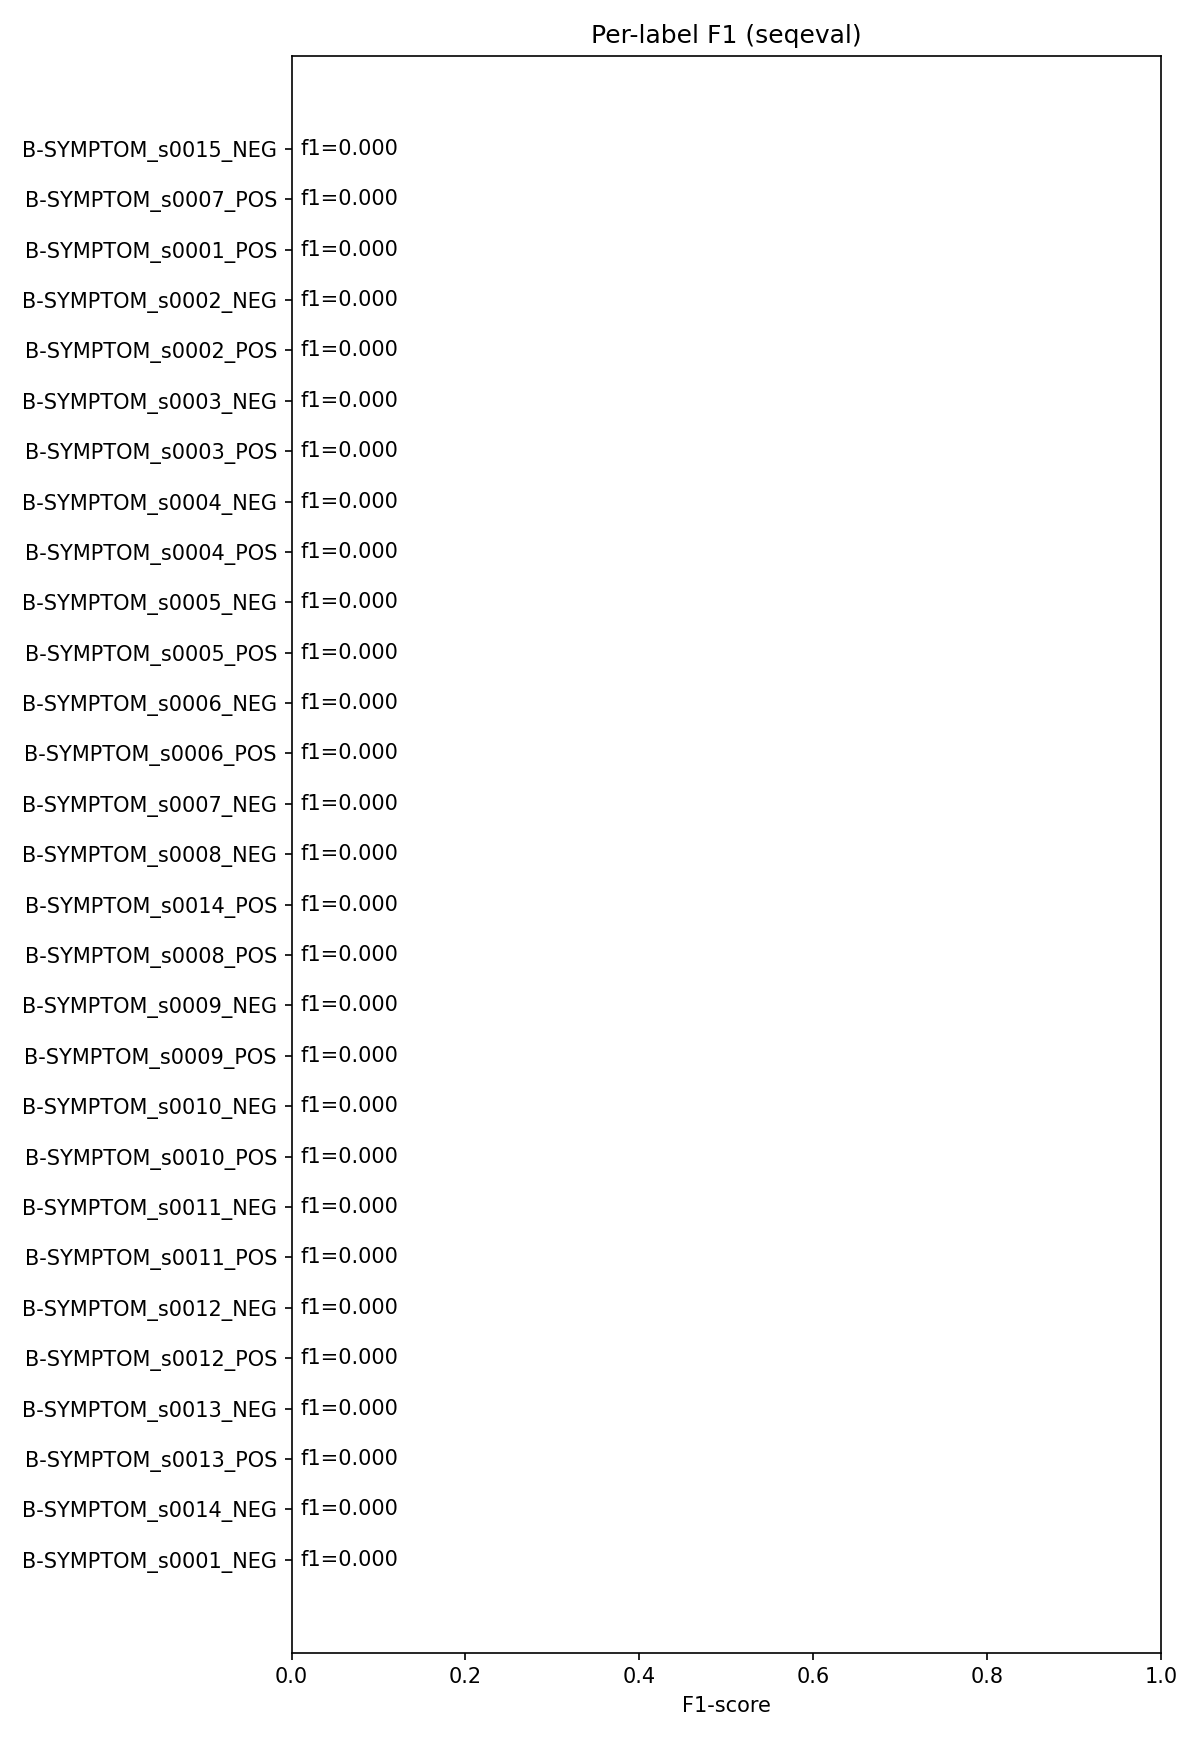

In [31]:
# Get predictions on validation set for detailed analysis
print("\n" + "=" * 60)
print("Computing per-label metrics for validation set...")
print("=" * 60)

val_predictions = trainer.predict(mini_test)

# Compute per-label metrics
val_per_label_metrics = compute_per_label_metrics(
    val_predictions, 
    id2label=id2label,
    #save_path="val_per_label_metrics.json"
)

print(f"\n✓ Per-label metrics computed for {len(val_per_label_metrics['f1'])} labels")
print(f"✓ Macro F1: {val_per_label_metrics['macro_f1']:.4f}")
print(f"✓ Metrics saved to: val_per_label_metrics.json")

# Generate and display the plot
val_plot_path = plot_metrics(
    metrics=val_per_label_metrics,
    #save_path="test_per_label_f1.png",
    top_k=30  # Plot top 30 labels by F1 score
)


print(f"✓ Validation plot saved to: {val_plot_path}")
display(Image(val_plot_path))